##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.

In [ ]:
! pip install -q kagglehub

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("pypiahmad/ucf-youtube-action-data-set")
print("Dataset downloaded to:", path)
print("Files/folders:", os.listdir(path))

100%|██████████| 604M/604M [00:08<00:00, 78.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/pypiahmad/ucf-youtube-action-data-set/versions/1
Files/folders: ['action_youtube_naudio']


In [3]:
dataset_path = path + "/action_youtube_naudio"
print("Dataset path exists:", os.path.exists(dataset_path))
print("Available classes:", os.listdir(dataset_path))

Dataset path exists: True
Available classes: ['swing', 'soccer_juggling', 'diving', 'biking', 'golf_swing', 'horse_riding', 'volleyball_spiking', 'trampoline_jumping', 'tennis_swing', 'walking', 'readme.txt', 'basketball']


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
student_name = "Shoug_Almoaibed"

selected_classes = ['basketball', 'biking', 'tennis_swing']

img_size = 48
sequence_length = 16
test_size = 0.2
random_state = 42
batch_size = 2
epochs = 10

In [6]:
def extract_frames(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < sequence_length:
        cap.release()
        return None

    skip = max(total_frames // sequence_length, 1)

    for i in range(sequence_length):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        success, frame = cap.read()

        if not success:
            break

        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = frame / 255.0
        frames.append(frame)

    cap.release()

    if len(frames) == sequence_length:
        return np.array(frames)
    return None

In [7]:
def load_dataset():
    features = []
    labels = []

    class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

    for cls in selected_classes:
        folder = os.path.join(dataset_path, cls)
        print(f"Loading: {cls}")

        count = 0
        for root, _, files in os.walk(folder):
            for file in files:
                if file.endswith((".avi", ".mp4", ".mov", ".mkv")):
                    path = os.path.join(root, file)
                    frames = extract_frames(path)

                    if frames is not None:
                        features.append(frames)
                        labels.append(class_to_idx[cls])
                        count += 1

        print(f"{count} videos loaded")

    return np.array(features), np.array(labels), class_to_idx

In [8]:
X, y, class_to_idx = load_dataset()

print("\nData shapes:")
print("X:", X.shape)
print("y:", y.shape)

y_cat = to_categorical(y, num_classes=len(selected_classes))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Loading: basketball
138 videos loaded
Loading: biking
145 videos loaded
Loading: tennis_swing
167 videos loaded

Data shapes:
X: (450, 16, 48, 48, 3)
y: (450,)
Training set: (360, 16, 48, 48, 3) (360, 3)
Testing set: (90, 16, 48, 48, 3) (90, 3)


In [9]:
model = Sequential([
    Conv3D(32, (3,3,3), activation='relu',
           input_shape=(sequence_length, img_size, img_size, 3)),
    MaxPooling3D((1,2,2)),

    Conv3D(64, (3,3,3), activation='relu'),
    MaxPooling3D((2,2,2)),

    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(selected_classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 14, 46, 46, 32) │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 14, 23, 23, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 12, 21, 21, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 6, 10, 10, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 10, 10, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,915,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,973,699 (18.97 MB)

 Trainable params: 4,973,699 (18.97 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 68s 462ms/step - accuracy: 0.3819 - loss: 1.1538 - val_accuracy: 0.4444 - val_loss: 0.9823
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 77s 429ms/step - accuracy: 0.5486 - loss: 1.0317 - val_accuracy: 0.6389 - val_loss: 0.9800
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 62s 431ms/step - accuracy: 0.6458 - loss: 0.8184 - val_accuracy: 0.6250 - val_loss: 1.2049
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 60s 418ms/step - accuracy: 0.7882 - loss: 0.4988 - val_accuracy: 0.7083 - val_loss: 0.6509
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 83s 427ms/step - accuracy: 0.8785 - loss: 0.3457 - val_accuracy: 0.7500 - val_loss: 0.7266
Epoch 6/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 62s 430ms/step - accuracy: 0.9167 - loss: 0.1988 - val_accuracy: 0.7778 - val_loss: 0.9828
Epoch 7/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 61s 423ms/step - accuracy: 0.9340 - loss: 0.1992 - val_accuracy: 0.7917 - val_loss: 0.8754


## 6. Model Evaluation

In [11]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7222 - loss: 0.5281

Test Accuracy: 0.7222


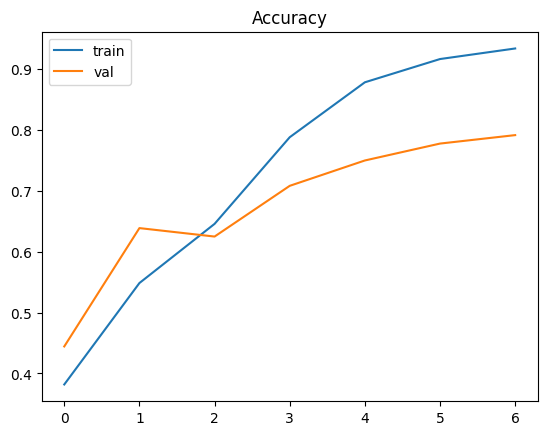

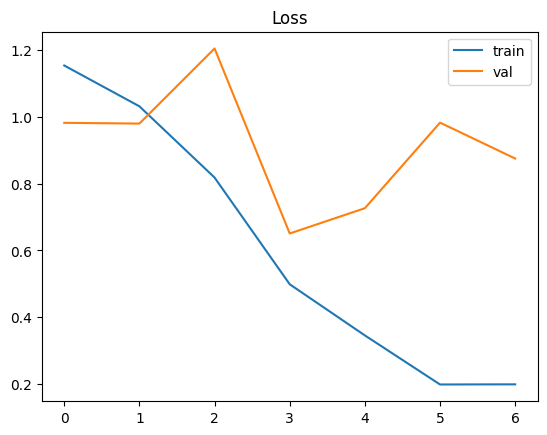

In [12]:
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


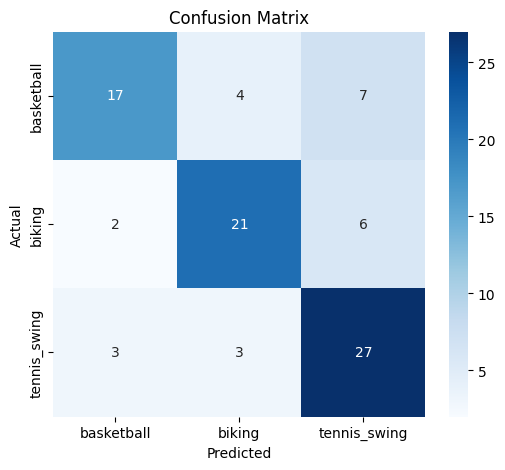


Classification Report:
              precision    recall  f1-score   support

  basketball       0.77      0.61      0.68        28
      biking       0.75      0.72      0.74        29
tennis_swing       0.68      0.82      0.74        33

    accuracy                           0.72        90
   macro avg       0.73      0.72      0.72        90
weighted avg       0.73      0.72      0.72        90



In [13]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=selected_classes,
            yticklabels=selected_classes,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=selected_classes))

In [14]:
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)

print(f"Model saved as: {save_path}")

Model saved as: Shoug_Almoaibed_ucf11_model.h5


In [ ]:
! pip install -q -U yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 47.7 MB/s eta 0:00:00


In [ ]:
# Download external videos from YouTube
! yt-dlp -o "basketball_test.%(ext)s" --extractor-args "youtube:player_client=default" "ytsearch1:basketball shooting practice"
! yt-dlp -o "biking_test.%(ext)s" --extractor-args "youtube:player_client=default" "ytsearch1:person biking road"
! yt-dlp -o "tennis_test.%(ext)s" --extractor-args "youtube:player_client=default" "ytsearch1:tennis forehand swing"

print([f for f in os.listdir() if f.startswith(("basketball_test", "biking_test", "tennis_test"))])

[youtube:search] Extracting URL: ytsearch1:basketball shooting practice
[download] Downloading playlist: basketball shooting practice
[youtube:search] query "basketball shooting practice": Downloading web client config
[youtube:search] query "basketball shooting practice" page 1: Downloading API JSON
[youtube:search] Playlist basketball shooting practice: Downloading 1 items of 1
[download] Downloading item 1 of 1
[youtube] Extracting URL: https://www.youtube.com/watch?v=gdSO0skE4Mg
[youtube] gdSO0skE4Mg: Downloading webpage
[youtube] gdSO0skE4Mg: Downloading android vr player API JSON
[info] gdSO0skE4Mg: Downloading 1 format(s): 399+251
[download] Destination: basketball_test.f399.mp4
[download] 100% of   99.46MiB in 00:00:02 at 34.12MiB/s
[download] Destination: basketball_test.f251.webm
[download] 100% of    6.53MiB in 00:00:00 at 17.53MiB/s
[Merger] Merging formats into "basketball_test.webm"
Deleting original file basketball_test.f399.mp4 (pass -k to keep)
Deleting original file b

In [ ]:
! yt-dlp -f mp4 -o basketball_test.mp4 "ytsearch1:basketball shooting practice"
! yt-dlp -f mp4 -o biking_test.mp4 "ytsearch1:person biking road"
! yt-dlp -f mp4 -o tennis_test.mp4 "ytsearch1:tennis forehand swing"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube:search] Extracting URL: ytsearch1:basketball shooting practice
[download] Downloading playlist: basketball shooting practice
[youtube:search] query "basketball shooting practice": Downloading web client config
[youtube:search] query "basketball shooting practice" page 1: Downloading API JSON
[youtube:search] Playlist basketball shooting practice: Downloading 1 items of 1
[download] Downloading item 1 of 1
[youtube] Extracting URL: https://www.youtube.com/watch?v=gdSO0skE4Mg
[youtube] gdSO0skE4Mg: Downloading webpage
[youtube] gdSO0skE4Mg: Downloading android vr player API JSON
[info] gdSO0skE4Mg: Downloading 1 format(s): 18
[download] basketball_t

In [21]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

def predict_video(video_path):
    frames = extract_frames(video_path)

    if frames is None:
        print(f"Could not process: {video_path}")
        return

    frames = np.expand_dims(frames, axis=0)

    prediction = model.predict(frames, verbose=0)[0]
    pred_idx = np.argmax(prediction)

    print(f"Video: {video_path}")
    print(f"Predicted class: {idx_to_class[pred_idx]}")
    print(f"Confidence: {prediction[pred_idx]:.4f}")
    print("-" * 40)

In [22]:
predict_video("basketball_test.mp4")
predict_video("biking_test.mp4")
predict_video("tennis_test.mp4")

Video: basketball_test.mp4
Predicted class: basketball
Confidence: 0.7248
----------------------------------------
Video: biking_test.mp4
Predicted class: biking
Confidence: 0.8140
----------------------------------------
Video: tennis_test.mp4
Predicted class: biking
Confidence: 0.4961
----------------------------------------
